In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
cleaned_file_path = BASE_DIR / "data" / "cleaned_transactions.csv"

df = pd.read_csv(cleaned_file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (2452, 8)

Columns:
['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount', 'Income/Expense', 'Currency']


In [2]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed", errors="coerce")

expense_df = df[df["Income/Expense"] == "Expense"].copy()

print("Date data type:", df["Date"].dtype)
print("Total transactions:", len(df))
print("Expense transactions:", len(expense_df))
print("Invalid dates:", df["Date"].isna().sum())

Date data type: datetime64[ns]
Total transactions: 2452
Expense transactions: 2173
Invalid dates: 0


In [3]:
expense_df["Month"] = expense_df["Date"].dt.to_period("M").astype(str)

monthly_spending = expense_df.groupby("Month")["Amount"].sum().reset_index()

print(monthly_spending.head())
print("\nNumber of months:", len(monthly_spending))

     Month   Amount
0  2015-01  33870.0
1  2015-02  24308.0
2  2015-03  32631.4
3  2015-04  24222.0
4  2015-05  63118.0

Number of months: 45


Matplotlib is building the font cache; this may take a moment.


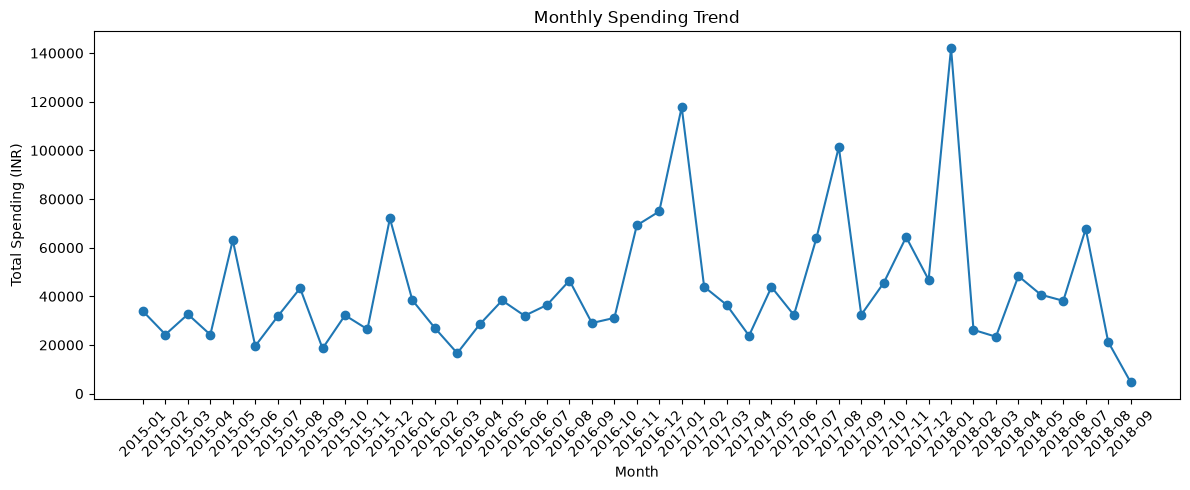

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_spending["Month"], monthly_spending["Amount"], marker="o")
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
category_spending = (
    expense_df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(category_spending.head(10))

                Category     Amount
0         Money transfer  606528.90
1             Investment  269858.00
2         Transportation  169053.78
3              Household  161645.58
4           subscription  114587.91
5                   Food   96393.10
6  Public Provident Fund   90000.00
7                  Other   87025.28
8                 Family   78582.20
9                 Health   66252.75


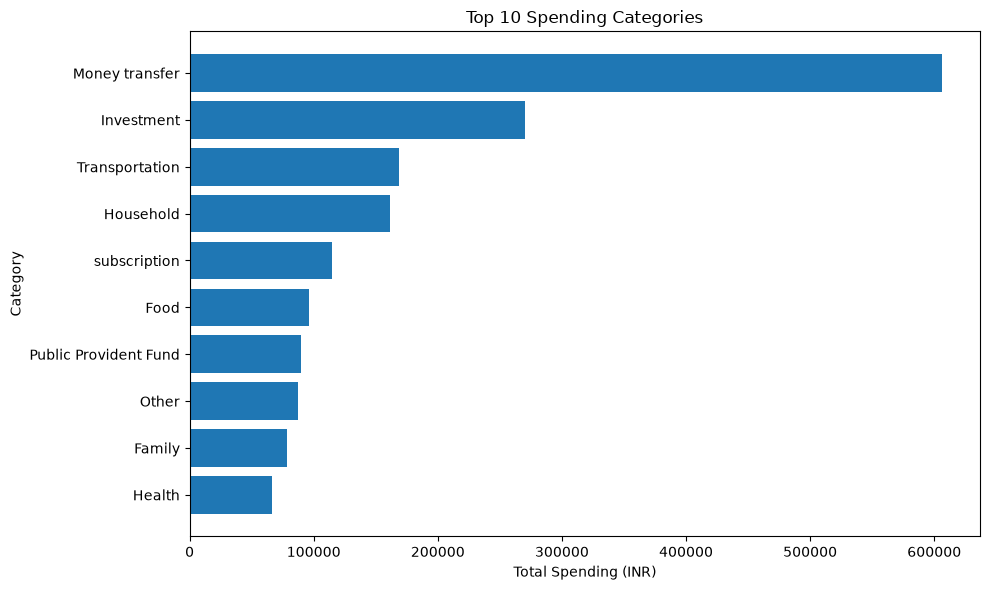

In [6]:
top_categories = category_spending.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["Category"], top_categories["Amount"])
plt.title("Top 10 Spending Categories")
plt.xlabel("Total Spending (INR)")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
income_df = df[df["Income/Expense"] == "Income"].copy()

income_df["Month"] = income_df["Date"].dt.to_period("M").astype(str)

monthly_income = income_df.groupby("Month")["Amount"].sum().reset_index()
monthly_income = monthly_income.rename(columns={"Amount": "Income"})

monthly_comparison = pd.merge(
    monthly_spending,
    monthly_income,
    on="Month",
    how="outer"
).fillna(0)

print(monthly_comparison.head(10))
print("\nNumber of months:", len(monthly_comparison))

     Month   Amount   Income
0  2015-01  33870.0      0.0
1  2015-02  24308.0  49806.0
2  2015-03  32631.4  70806.0
3  2015-04  24222.0  49306.0
4  2015-05  63118.0  47859.0
5  2015-06  19567.0  47859.0
6  2015-07  31735.0  47859.0
7  2015-08  43340.0  49806.0
8  2015-09  18577.0  54606.0
9  2015-10  32217.0  49806.0

Number of months: 45


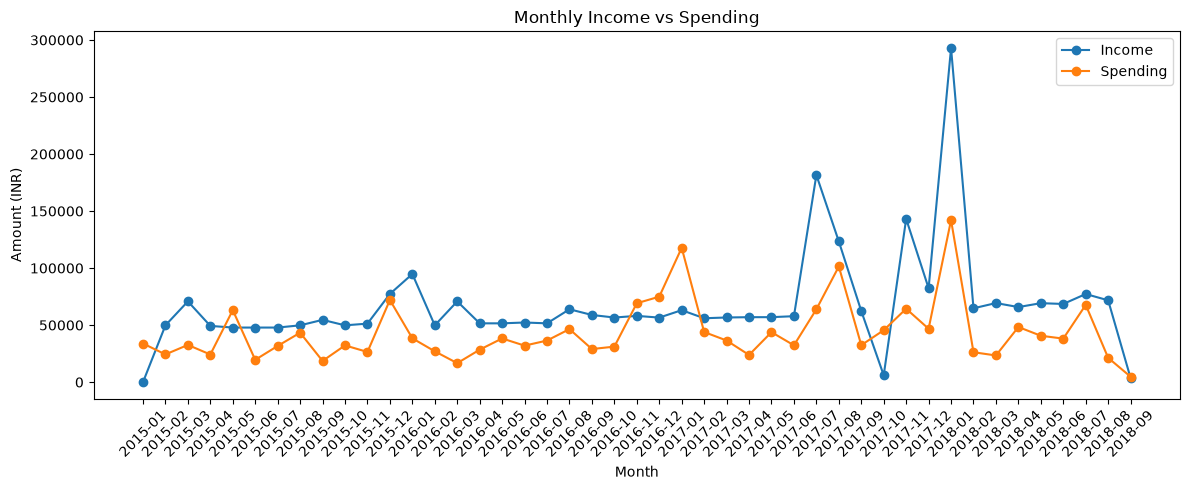

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_comparison["Month"],
    monthly_comparison["Income"],
    marker="o",
    label="Income"
)

plt.plot(
    monthly_comparison["Month"],
    monthly_comparison["Amount"],
    marker="o",
    label="Spending"
)

plt.title("Monthly Income vs Spending")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
monthly_comparison["Savings"] = (
    monthly_comparison["Income"] - monthly_comparison["Amount"]
)

print(monthly_comparison.head(10))

print("\nMonths with spending higher than income:")
print((monthly_comparison["Savings"] < 0).sum())

     Month   Amount   Income  Savings
0  2015-01  33870.0      0.0 -33870.0
1  2015-02  24308.0  49806.0  25498.0
2  2015-03  32631.4  70806.0  38174.6
3  2015-04  24222.0  49306.0  25084.0
4  2015-05  63118.0  47859.0 -15259.0
5  2015-06  19567.0  47859.0  28292.0
6  2015-07  31735.0  47859.0  16124.0
7  2015-08  43340.0  49806.0   6466.0
8  2015-09  18577.0  54606.0  36029.0
9  2015-10  32217.0  49806.0  17589.0

Months with spending higher than income:
7


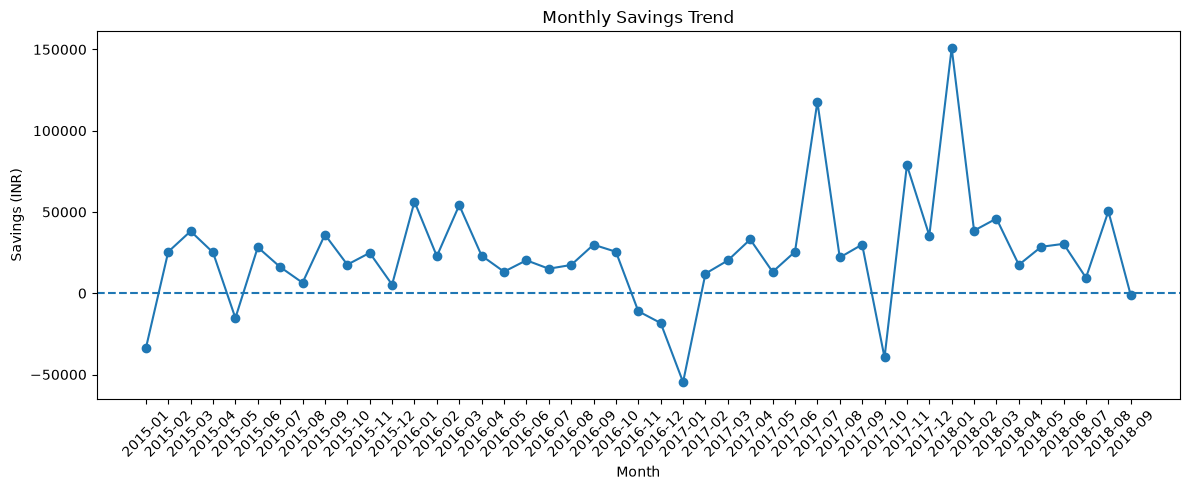

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_comparison["Month"],
    monthly_comparison["Savings"],
    marker="o"
)

plt.axhline(y=0, linestyle="--")

plt.title("Monthly Savings Trend")
plt.xlabel("Month")
plt.ylabel("Savings (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
mode_spending = (
    expense_df.groupby("Mode")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(mode_spending)

                    Mode      Amount
0  Saving Bank account 1  1575728.46
1            Credit Card   205254.01
2                   Cash   173421.00
3             Debit Card      942.36
4  Saving Bank account 2       34.70


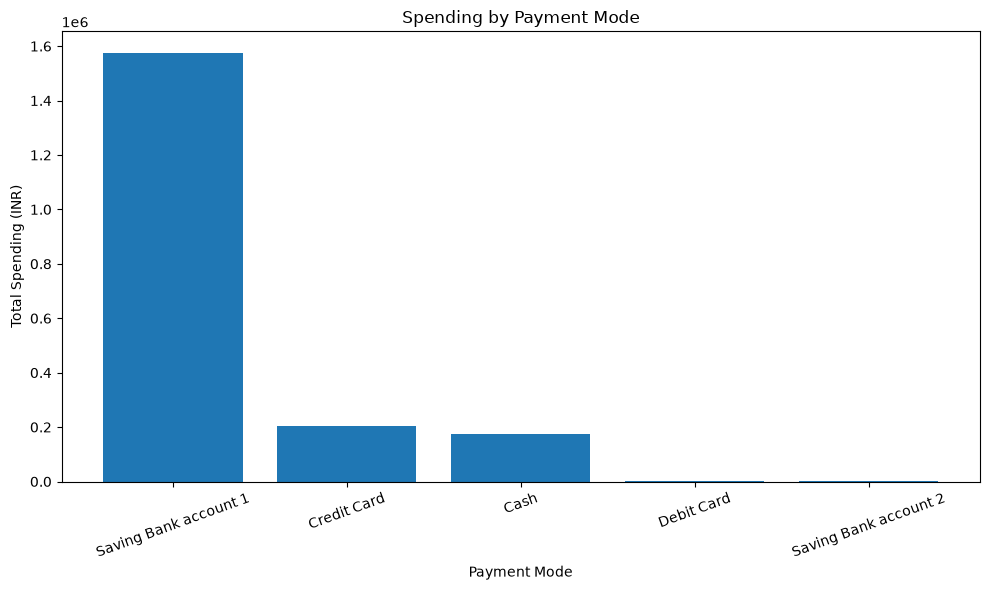

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(mode_spending["Mode"], mode_spending["Amount"])

plt.title("Spending by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Spending (INR)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:
expense_df["Year"] = expense_df["Date"].dt.year

yearly_spending = (
    expense_df.groupby("Year")["Amount"]
    .sum()
    .reset_index()
)

print(yearly_spending)

   Year     Amount
0  2015  422074.40
1  2016  468084.20
2  2017  652587.67
3  2018  412634.26


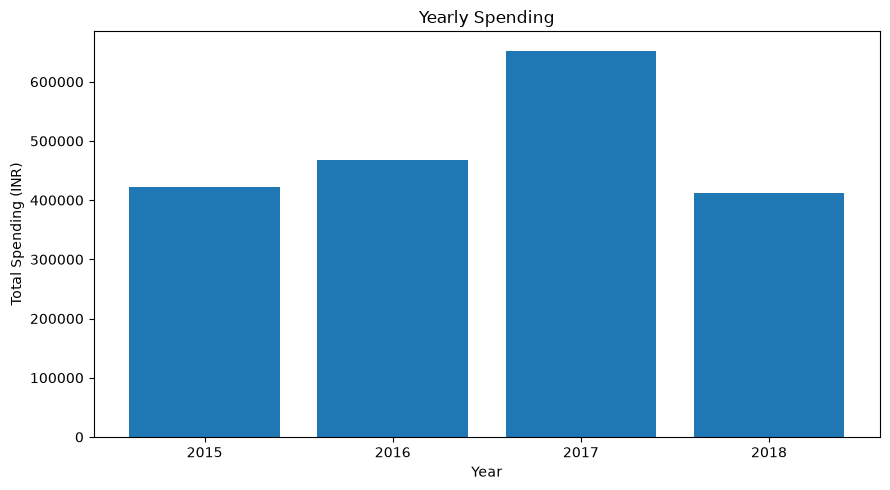

In [14]:
plt.figure(figsize=(9, 5))

plt.bar(
    yearly_spending["Year"].astype(str),
    yearly_spending["Amount"]
)

plt.title("Yearly Spending")
plt.xlabel("Year")
plt.ylabel("Total Spending (INR)")
plt.tight_layout()
plt.show()

In [15]:
highest_spending_month = monthly_spending.loc[
    monthly_spending["Amount"].idxmax()
]

lowest_spending_month = monthly_spending.loc[
    monthly_spending["Amount"].idxmin()
]

print("Highest spending month:")
print(highest_spending_month)

print("\nLowest spending month:")
print(lowest_spending_month)

Highest spending month:
Month      2018-01
Amount    142080.9
Name: 36, dtype: object

Lowest spending month:
Month     2018-09
Amount     4724.0
Name: 44, dtype: object


In [16]:
monthly_comparison.to_csv(
    BASE_DIR / "data" / "monthly_financial_summary.csv",
    index=False
)

category_spending.to_csv(
    BASE_DIR / "data" / "category_spending.csv",
    index=False
)

mode_spending.to_csv(
    BASE_DIR / "data" / "mode_spending.csv",
    index=False
)

yearly_spending.to_csv(
    BASE_DIR / "data" / "yearly_spending.csv",
    index=False
)

print("Week 5 analysis files saved successfully.")
print("monthly_financial_summary.csv")
print("category_spending.csv")
print("mode_spending.csv")
print("yearly_spending.csv")

Week 5 analysis files saved successfully.
monthly_financial_summary.csv
category_spending.csv
mode_spending.csv
yearly_spending.csv
